In [ ]:
 # --- CELL 1: Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Set visual style
color_pal = sns.color_palette()
plt.style.use('fivethirtyeight')

In [ ]:
# --- CELL 2: Load Data ---
# Reading the specific file you uploaded: AEP_hourly.csv
df = pd.read_csv('AEP_hourly.csv')

# Convert the 'Datetime' column to a proper datetime object
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)

# Sort index just to be safe (time series must be ordered)
df = df.sort_index()

# Display first few rows
print("Data Head:")
print(df.head())

Data Head:
                      AEP_MW
Datetime                    
2004-10-01 01:00:00  12379.0
2004-10-01 02:00:00  11935.0
2004-10-01 03:00:00  11692.0
2004-10-01 04:00:00  11597.0
2004-10-01 05:00:00  11681.0


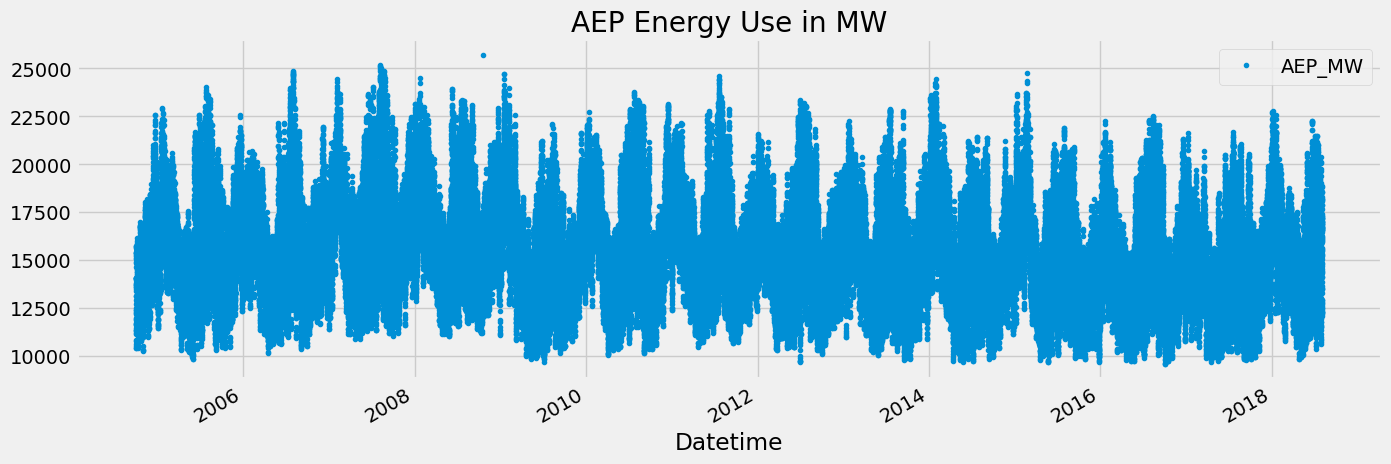

In [ ]:
df.plot(style='.',
        figsize=(15, 5),
        color=color_pal[0],
        title='AEP Energy Use in MW')
plt.show()

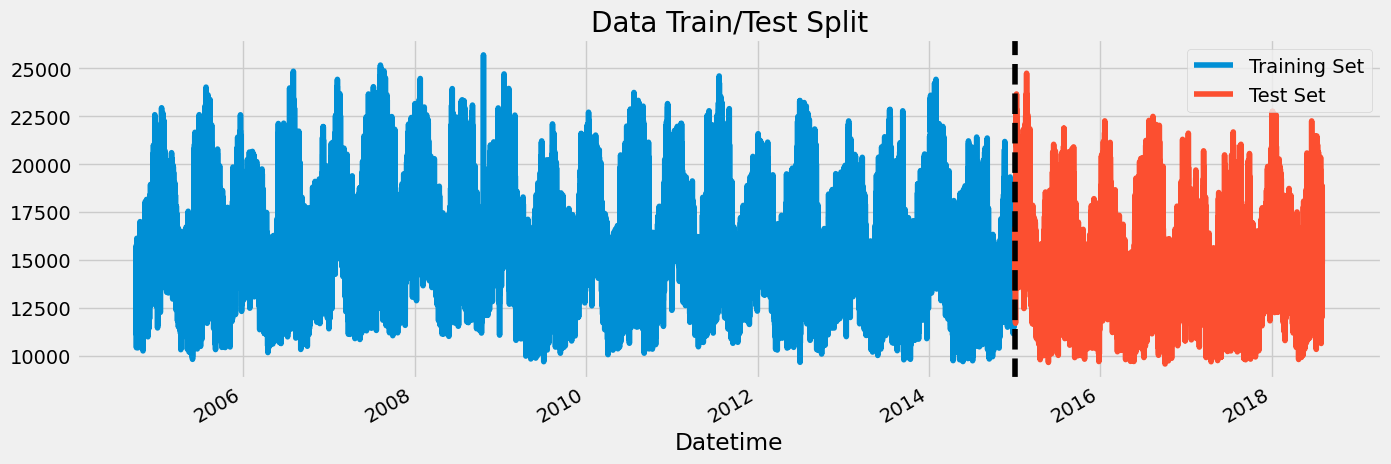

In [ ]:
# --- CELL 4: Train / Test Split ---
# We split based on a specific date (Cutoff: Jan 1st, 2015)
train = df.loc[df.index < '01-01-2015']
test = df.loc[df.index >= '01-01-2015']

# Plot the split to see it visually
fig, ax = plt.subplots(figsize=(15, 5))
train.plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test.plot(ax=ax, label='Test Set')
ax.axvline('01-01-2015', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()


In [ ]:
# --- UPDATE THIS IN CELL 5 ---

def create_features_advanced(df):
    df = df.copy()

    # 1. Standard Calendar Features (Keep these)
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear

    # 2. LAG FEATURES (The "Memory")
    # "What was the energy use 24 hours ago?"
    df['lag_24h'] = df['AEP_MW'].shift(24)
    # "What was the energy use 1 week (168 hours) ago?"
    df['lag_1week'] = df['AEP_MW'].shift(168)

    # 3. ROLLING WINDOWS (The "Trend")
    # "What was the average energy use over the last 24 hours?"
    # We shift by 1 first to ensure we only use PAST data to predict NOW
    df['rolling_mean_24h'] = df['AEP_MW'].shift(1).rolling(window=24).mean()

    return df

# Apply the function
df = create_features_advanced(df)

# CRITICAL STEP: Lags create empty rows (NaNs) at the start.
# XGBoost can handle them, but for evaluation, it's safer to drop the first week.
df = df.dropna()


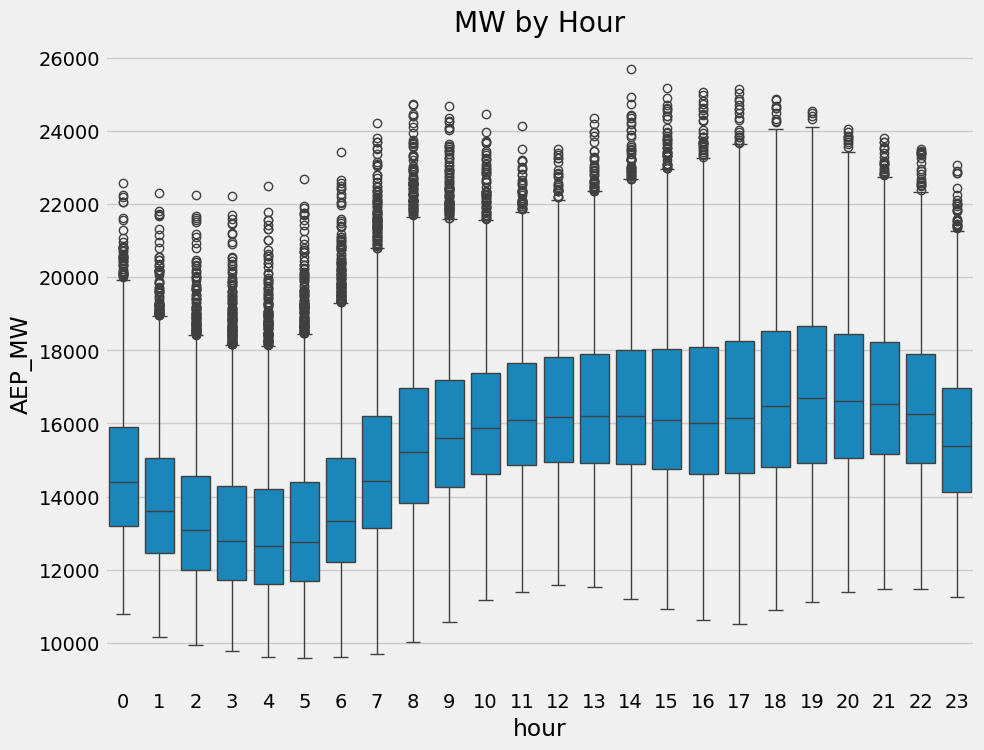

/tmp/ipython-input-1811676472.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='AEP_MW', palette='Blues')


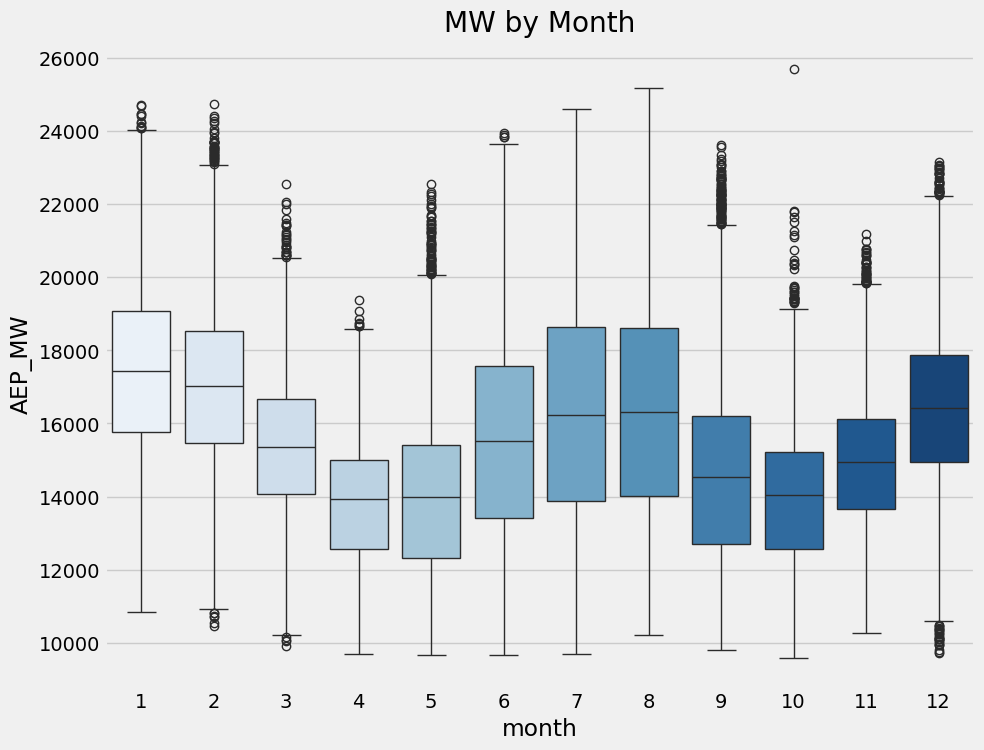

In [ ]:
# --- CELL 6: Visualize Feature Relationships ---
# Boxplot: Energy use by Hour of Day
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='hour', y='AEP_MW')
ax.set_title('MW by Hour')
plt.show()

# Boxplot: Energy use by Month
fig, ax = plt.subplots(figsize=(10, 8))
sns.boxplot(data=df, x='month', y='AEP_MW', palette='Blues')
ax.set_title('MW by Month')
plt.show()

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Setup the Splitter
# n_splits=5: We will test the model on 5 different time periods
# test_size: We test on approx 1 year of data each time
tscv = TimeSeriesSplit(n_splits=5, test_size=24*365*1)

# Ensure these match your feature engineering function
FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag_24h', 'lag_1week', 'rolling_mean_24h']
TARGET = 'AEP_MW'

print("--- Starting Time Series Cross-Validation Loop ---")

# 2. The Training Loop
fold = 0
for train_index, test_index in tscv.split(df):
    fold += 1

    # A. Split the Data
    train = df.iloc[train_index]
    test = df.iloc[test_index]

    X_train = train[FEATURES]
    y_train = train[TARGET]
    X_test = test[FEATURES]
    y_test = test[TARGET]

    # B. Initialize the Model
    reg = xgb.XGBRegressor(base_score=0.5,
                           booster='gbtree',
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:squarederror',
                           max_depth=3,
                           learning_rate=0.01)

    # C. Train (Fit)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=False) # Keep it silent to reduce clutter

    # D. Predict
    # We overwrite 'y_pred' in every loop, so at the end,
    # it holds the predictions for the LAST (most recent) fold.
    y_pred = reg.predict(X_test)

    # Optional: Quick progress check
    current_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"Fold {fold} finished. RMSE: {current_rmse:.2f}")

print("--- Cross-Validation Complete ---")
print("Ready for Evaluation!")

--- Starting Time Series Cross-Validation Loop ---
Fold 1 finished. RMSE: 951.06
Fold 2 finished. RMSE: 874.10
Fold 3 finished. RMSE: 825.61
Fold 4 finished. RMSE: 851.87
Fold 5 finished. RMSE: 880.70
--- Cross-Validation Complete ---
Ready for Evaluation!


In [ ]:
# --- CELL 8: Train the Model ---
# We fit the model using the training data and evaluate on the test data
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100) # Print progress every 100 trees


[0]	validation_0-rmse:15602.47707	validation_1-rmse:15008.55201
[100]	validation_0-rmse:5810.32262	validation_1-rmse:5551.66664
[200]	validation_0-rmse:2321.18670	validation_1-rmse:2229.21472
[300]	validation_0-rmse:1215.83114	validation_1-rmse:1196.09464
[400]	validation_0-rmse:948.75634	validation_1-rmse:957.76371
[500]	validation_0-rmse:890.04180	validation_1-rmse:910.35580
[600]	validation_0-rmse:871.06374	validation_1-rmse:898.79596
[700]	validation_0-rmse:860.17376	validation_1-rmse:892.52482
[800]	validation_0-rmse:852.33585	validation_1-rmse:888.68383
[900]	validation_0-rmse:845.58034	validation_1-rmse:884.82154
[999]	validation_0-rmse:838.92118	validation_1-rmse:880.70305


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

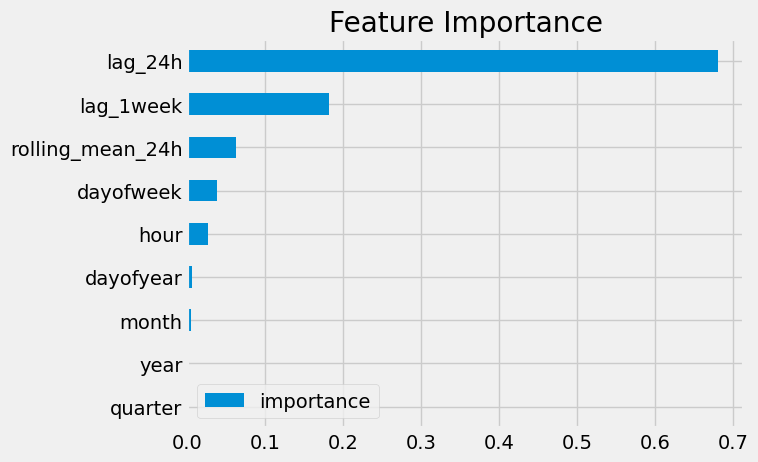

In [ ]:
# --- CELL 9: Feature Importance ---
# See which features mattered most
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()

/tmp/ipython-input-3406171691.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(X_test)


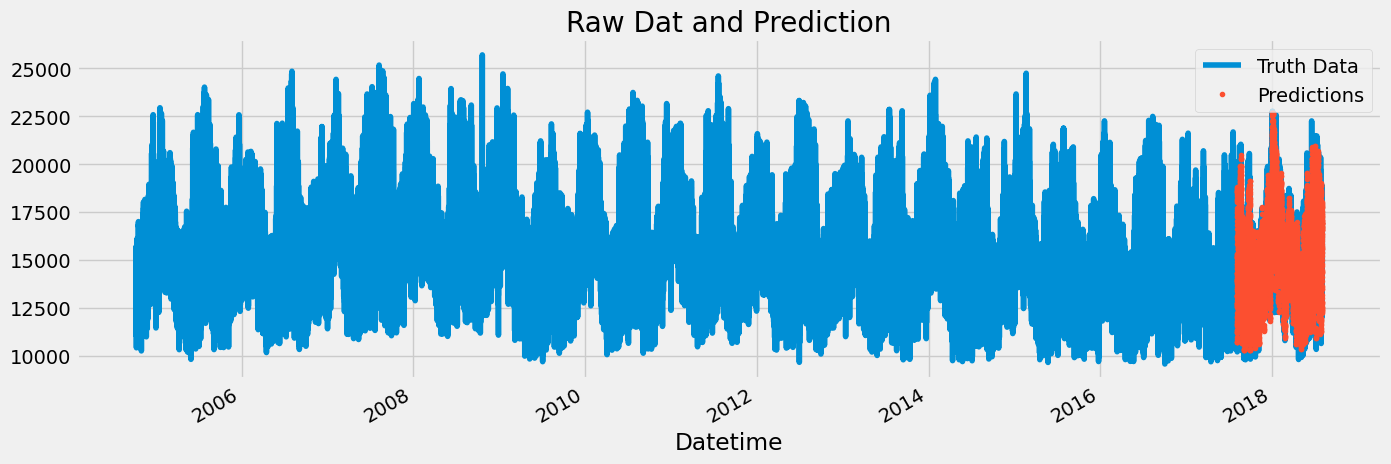

In [ ]:
# --- CELL 10: Forecast on Test Set ---
# Make predictions
test['prediction'] = reg.predict(X_test)

# Merge predictions back into the main dataframe for plotting
df = df.merge(test[['prediction']], how='left', left_index=True, right_index=True)

# Visualize: Actual vs Prediction
ax = df[['AEP_MW']].plot(figsize=(15, 5))
df['prediction'].plot(ax=ax, style='.')
plt.legend(['Truth Data', 'Predictions'])
ax.set_title('Raw Dat and Prediction')
plt.show()

In [ ]:
# --- CELL 11: Calculate Error Score (RMSE) ---
score = np.sqrt(mean_squared_error(test['AEP_MW'], test['prediction']))
print(f'RMSE Score on Test set: {score:0.2f}')

# --- CELL 12: Error Analysis (Worst Predictions) ---
# Calculate the absolute error for every single prediction
test['error'] = np.abs(test[TARGET] - test['prediction'])
test['date'] = test.index.date

# Look at the worst predicted days
print("\nTop 5 Worst Predicted Days:")
print(test.groupby(['date'])['error'].mean().sort_values(ascending=False).head(5))

RMSE Score on Test set: 880.70

Top 5 Worst Predicted Days:
date
2018-01-08    2563.875651
2018-01-13    2167.515951
2018-02-02    2038.827922
2017-12-31    1972.640625
2017-12-27    1853.931437
Name: error, dtype: float64


In [ ]:
# --- CELL: UNIVERSAL EVALUATION FUNCTION ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name="Model"):


    # --- 1. Calculate Core Metrics ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    # Calculate MAPE (Mean Absolute Percentage Error)
    # Adding a small epsilon (1e-10) to avoid "Divide by Zero" errors if data has 0s
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    accuracy = 100 - mape

    # --- 2. Print Report ---
    print(f"================ {model_name} REPORT ================")
    print(f"   RMSE (Key Metric)     : {rmse:.2f}")
    print(f"   MAE (Avg Error)       : {mae:.2f}")
    print(f"   MAPE (Percentage Err) : {mape:.2f}%")
    print(f"   Accuracy (Approx)     : {accuracy:.2f}%")
    print(f"   R² Score              : {r2:.4f}")
    print("=====================================================")

# --- AUTOMATIC EXECUTION ---
# This block attempts to run the function automatically based on the variables
# from your previous cells (Part 1 or Part 2).

try:
    # Case A: You are using the DataFrame method (Part 1 - Basic)
    # Checks if 'test' dataframe exists and has a 'prediction' column
    evaluate_model(test['AEP_MW'], test['prediction'], model_name="XGBoost Basic")

except (NameError, KeyError):
    try:
        # Case B: You are using the Arrays method (Part 2 - Advanced Loop)
        # Checks if y_test and y_pred variables exist
        evaluate_model(y_test, y_pred, model_name="XGBoost Improved")
    except NameError:
        # Case C: Variables not found (Safety net)
        print("Function 'evaluate_model' is ready!")
        print("To use it, run: evaluate_model(your_actual_data, your_predictions)")

================ XGBoost Basic REPORT ================
   RMSE (Key Metric)     : 880.70
   MAE (Avg Error)       : 678.84
   MAPE (Percentage Err) : 4.47%
   Accuracy (Approx)     : 95.53%
   R² Score              : 0.8696
